# 01 — Data QC

Exploratory data-quality check for the CRC histology patches used in this project.

Goals:
- confirm class balance across `train` / `validation` / `test`;
- look at a sample grid of patches per tissue class;
- check global brightness/color statistics per class, as an early, visual preview of the color-shortcut question investigated in `docs/RESULTS.md`.

If the real CRC pilot metadata (`data/metadata/crc_pilot_metadata.csv`) has not been generated yet (see README → "Train a model"), this notebook falls back to the small synthetic dataset so it can still run end to end without downloading anything.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

sys.path.insert(0, str(Path.cwd().parents[0]))

from src.datasets.synthetic import (
    generate_synthetic_histology_dataset,
)

sns.set_theme(style="whitegrid")

In [5]:
REAL_METADATA_PATH = Path(
    "./data/metadata/crc_pilot_metadata.csv"
)

if REAL_METADATA_PATH.exists():
    metadata = pd.read_csv(REAL_METADATA_PATH)
    print(f"Loaded real metadata: {REAL_METADATA_PATH}")
else:
    print(
        "Real CRC pilot metadata not found — "
        "generating a small synthetic dataset instead. "
        "See README for how to prepare the real pilot data."
    )
    metadata = generate_synthetic_histology_dataset(
        output_dir="../data/raw/synthetic_patches",
        metadata_path="../data/metadata/synthetic_metadata.csv",
        num_patients=12,
        slides_per_patient=2,
        patches_per_slide=8,
        image_size=128,
        seed=42,
    )

metadata.shape

Loaded real metadata: data\metadata\crc_pilot_metadata.csv


(7200, 10)

## Class balance

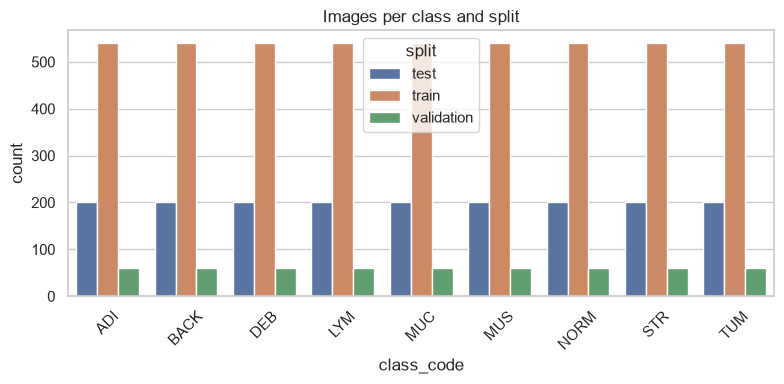

In [6]:
class_column = (
    "class_code" if "class_code" in metadata.columns else "label"
)
split_column = (
    "split" if "split" in metadata.columns else None
)

if split_column is not None:
    counts = (
        metadata.groupby([split_column, class_column])
        .size()
        .rename("count")
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(
        data=counts,
        x=class_column,
        y="count",
        hue=split_column,
        ax=ax,
    )
    ax.set_title("Images per class and split")
    plt.xticks(rotation=45)
    plt.tight_layout()
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.countplot(data=metadata, x=class_column, ax=ax)
    ax.set_title("Images per class")
    plt.tight_layout()

## Sample grid

A few example patches per class, to visually sanity-check that images loaded correctly and classes look distinct.

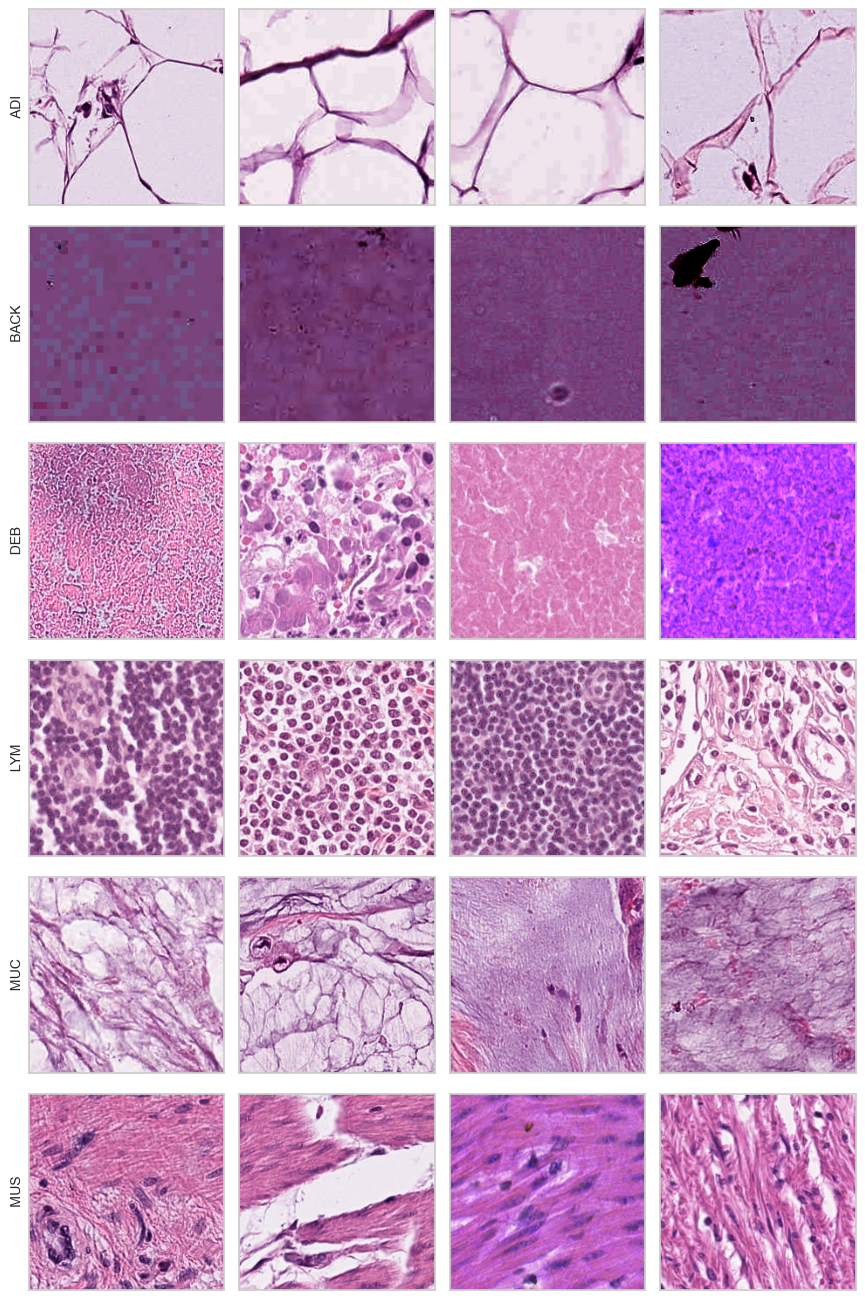

In [7]:
unique_classes = sorted(
    metadata[class_column].unique(),
    key=str,
)[:6]
samples_per_class = 4

fig, axes = plt.subplots(
    nrows=len(unique_classes),
    ncols=samples_per_class,
    figsize=(2.2 * samples_per_class, 2.2 * len(unique_classes)),
)

for row_index, class_value in enumerate(unique_classes):
    class_rows = metadata[
        metadata[class_column] == class_value
    ].sample(
        min(samples_per_class, (metadata[class_column] == class_value).sum()),
        random_state=0,
    )

    for col_index, (_, row) in enumerate(class_rows.iterrows()):
        ax = axes[row_index, col_index] if len(unique_classes) > 1 else axes[col_index]
        with Image.open(row["path"]) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_xticks([])
        ax.set_yticks([])
        if col_index == 0:
            ax.set_ylabel(str(class_value), fontsize=10)

plt.tight_layout()

## Brightness / color preview

A quick, spatially-independent brightness check per class. This is a lightweight preview of the same question that `src/analysis/color_features.py` and the RGB-HSV PCA baseline answer rigorously in `docs/RESULTS.md`: how much class signal is already visible from color/brightness alone, before any representation learning happens.

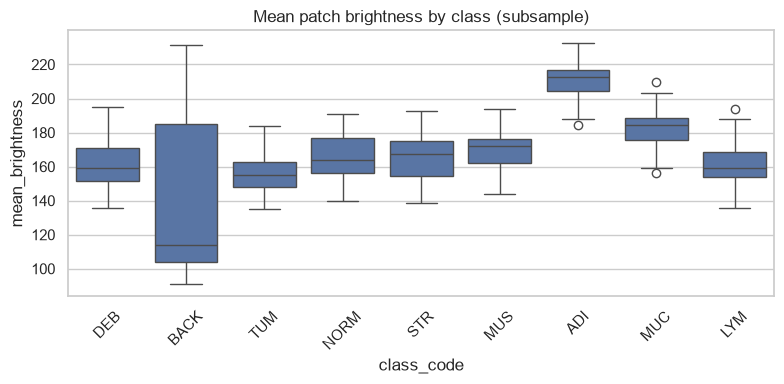

In [8]:
def mean_brightness(path: str) -> float:
    with Image.open(path) as image:
        array = np.asarray(image.convert("RGB"), dtype=np.float32)
    return float(array.mean())

sample_for_brightness = metadata.sample(
    min(len(metadata), 300),
    random_state=0,
).copy()
sample_for_brightness["mean_brightness"] = (
    sample_for_brightness["path"].apply(mean_brightness)
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=sample_for_brightness,
    x=class_column,
    y="mean_brightness",
    ax=ax,
)
ax.set_title("Mean patch brightness by class (subsample)")
plt.xticks(rotation=45)
plt.tight_layout()

## Notes

- If classes already separate visibly by brightness/color here, that is an early warning sign of the shortcut described in the project README, and motivates the grayscale and color-denoising VAE variants.
- This notebook is a quick visual check, not a statistical claim — see `docs/RESULTS.md` for the rigorous, bootstrap-validated version of this question.